In [41]:
import snowflake.connector
import pandas as pd
from cryptography.hazmat.primitives import serialization
from cryptography.hazmat.backends import default_backend
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
with open("/Users/maithiliwade/Documents/Data Projects/Olist/python_analysis/rsa_key.pem", "rb") as key_file:
    private_key = serialization.load_pem_private_key(
        key_file.read(),
        password=None,
        backend=default_backend()
    )

conn = snowflake.connector.connect(
    account='ELJXLGQ-LE82203',
    user='MAITHILIWADE',
    private_key=private_key,
    database='PC_DBT_DB',
    warehouse='PC_DBT_WH',
    role='ACCOUNTADMIN'
)

In [43]:
cursor = conn.cursor()
cursor.execute("SELECT * FROM PC_DBT_DB.dbt_MWade_marts.mart_rfm_segments")
df = cursor.fetch_pandas_all()
print(df.head())


                        CUSTOMER_ID                CUSTOMER_UNIQUE_ID  \
0  197a2a6a77da93f678ea0d379f21da0a  6ba987d564bad1f9da8e14b9d3b71c8f   
1  a73c1f73f5772cf801434bf984b0b1a7  968fac81e2c44fb6c1e3ac2a45e6a102   
2  3532ba38a3fd242259a514ac2b6ae6b6  4fa4365000c7090fcb8cad5713c6d3db   
3  a790343ca6f3fee08112d678b43aa7c5  317cfc692e3f86c45c95697c61c853a6   
4  184e8e8e48937145eb96c721ef1f0747  bd06ce0e06ad77a7f681f1a4960a3cc6   

        CITY STATE  TOTAL_ORDERS  TOTAL_SPENT    FIRST_ORDER_DATE  \
0  sao paulo    SP             1         0.00                 NaT   
1  sao paulo    SP             1         0.00                 NaT   
2  sao paulo    SP             1         0.00                 NaT   
3   paulinia    SP             2         9.59 2018-08-25 21:30:15   
4  sao paulo    SP             1        10.07 2017-09-13 19:25:38   

      LAST_ORDER_DATE  RECENCY_DAYS  RECENCY_SCORE  FREQUENCY_SCORE  \
0                 NaT           NaN              1                5   
1   

/var/folders/rm/9cthtyfn3tq60r_svg4nkj7c0000gn/T/ipykernel_91127/1673149954.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')


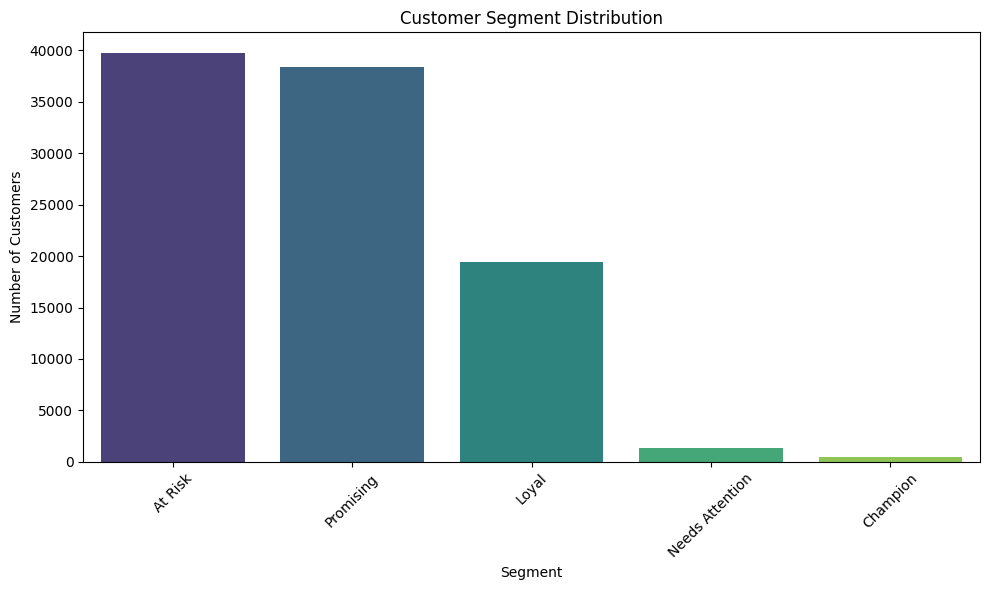

Chart Saved


In [44]:
# Viz 1: Customer segment distribution
segment_counts = df['CUSTOMER_SEGMENT'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')
plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('rfm_segments.png')
plt.show()
print('Chart Saved')

/var/folders/rm/9cthtyfn3tq60r_svg4nkj7c0000gn/T/ipykernel_91127/429363219.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_spend.index, y=segment_spend.values, palette='magma')


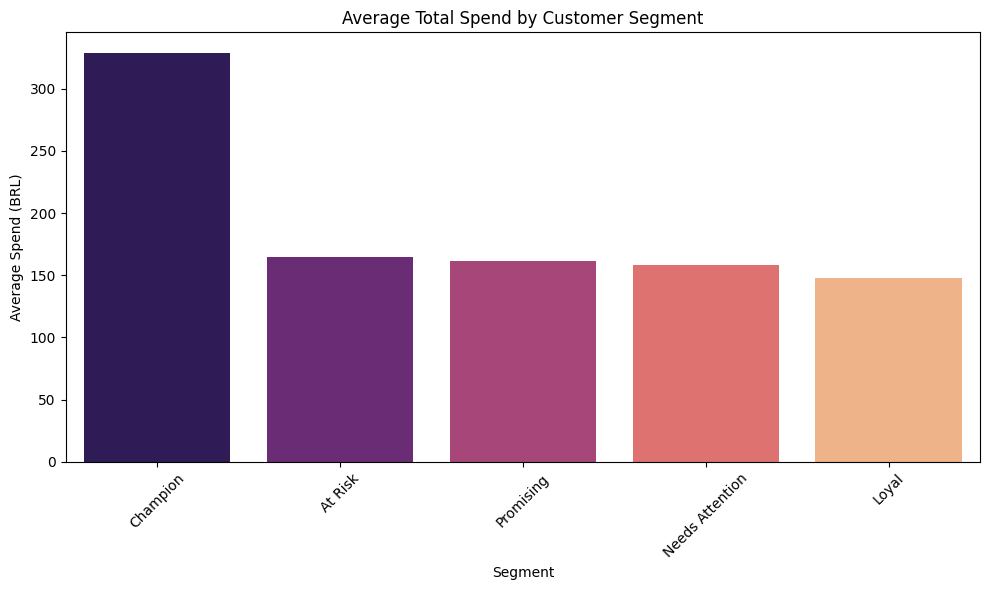

Chart 2 saved


In [45]:
# Viz 2: Average spend by segment 
plt.figure(figsize=(10, 6))
segment_spend = df.groupby('CUSTOMER_SEGMENT')['TOTAL_SPENT'].mean().sort_values(ascending=False)
sns.barplot(x=segment_spend.index, y=segment_spend.values, palette='magma')
plt.title('Average Total Spend by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Average Spend (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('segment_spend.png')
plt.show()
print('Chart 2 saved')

In [46]:
cursor = conn.cursor()
cursor.execute("SELECT * FROM PC_DBT_DB.dbt_MWade_marts.mart_cohort_retention")
cohort_df = cursor.fetch_pandas_all()
cohort_df.head()


,COUNT_OF_CUSTOMERS,COHORT_MONTH,MONTH_INDEX
0,7132,2018-03-01,0
1,6829,2018-05-01,0
2,317,2016-10-01,0
3,3637,2017-05-01,0
4,4543,2017-10-01,0


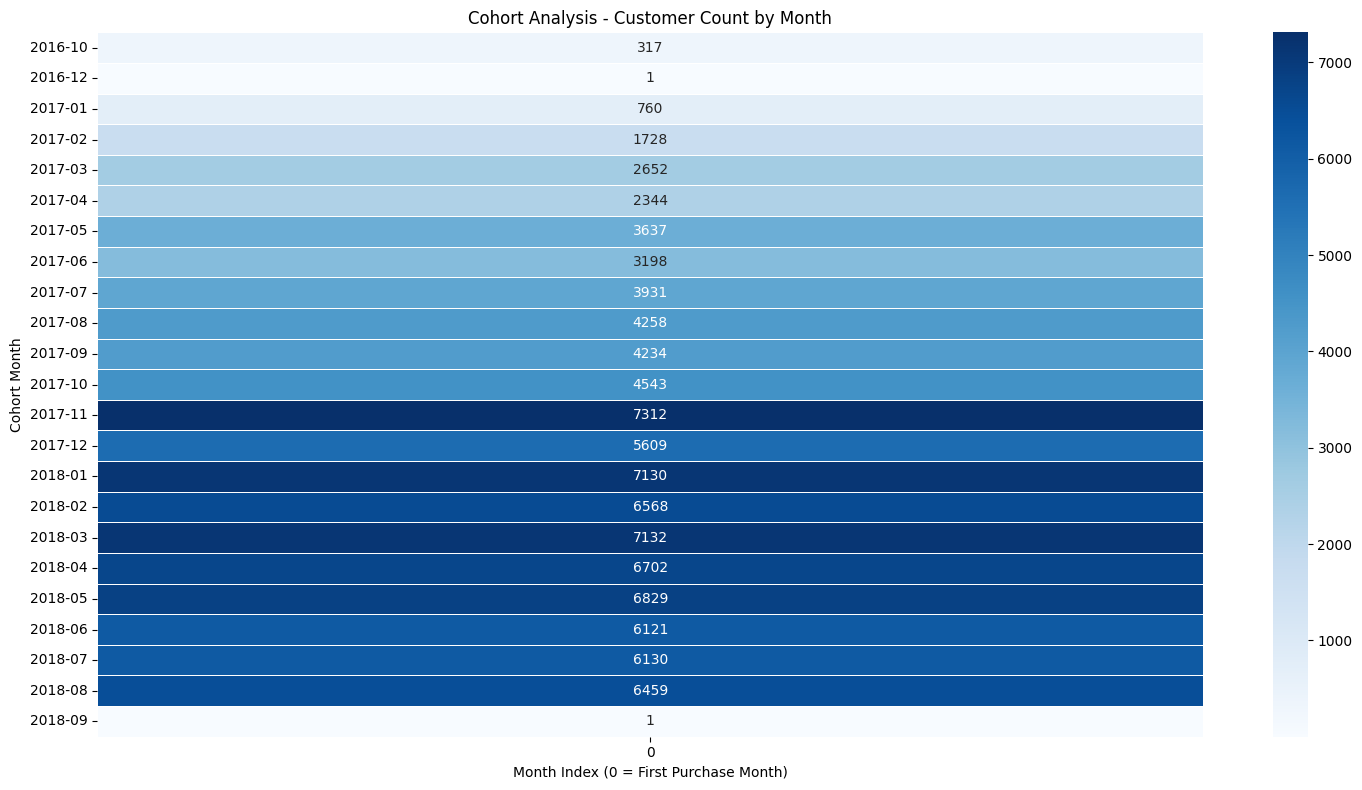

In [49]:
#Cohort retention heatmap 
cohort_pivot = cohort_df.pivot_table(
    index='COHORT_MONTH',
    columns='MONTH_INDEX',
    values='COUNT_OF_CUSTOMERS'
)

cohort_pivot.index = pd.to_datetime(cohort_pivot.index).strftime('%Y-%m')

plt.figure(figsize=(15, 8))
sns.heatmap(cohort_pivot,
            annot=True,
            fmt='.0f',
            cmap='Blues',
            linewidths=0.5)
plt.title('Cohort Analysis - Customer Count by Month')
plt.xlabel('Month Index (0 = First Purchase Month)')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.savefig('cohort_retention.png')

/var/folders/rm/9cthtyfn3tq60r_svg4nkj7c0000gn/T/ipykernel_91127/190021904.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


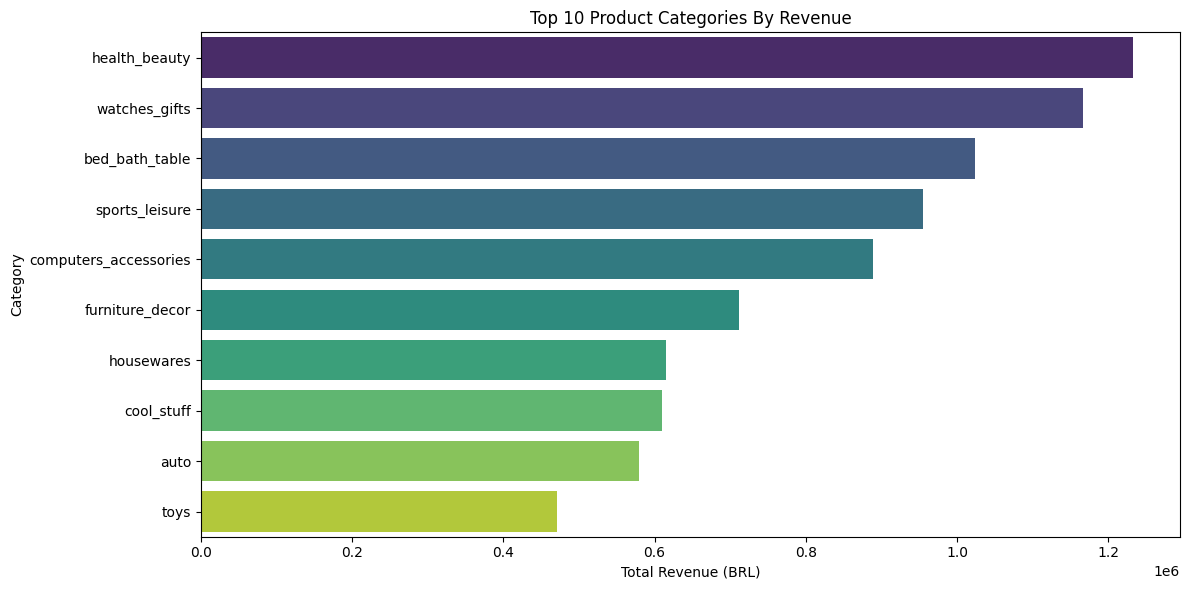

In [50]:
#Load revenue analysis data 
cursor = conn.cursor()
cursor.execute("SELECT * FROM PC_DBT_DB.dbt_MWade_marts.mart_revenue_analysis WHERE ORDER_STATUS = 'delivered'")
revenue_df = cursor.fetch_pandas_all()

#top 10 categories by revenue
top_categories = revenue_df.groupby('PRODUCT_CATEGORY_NAME_ENGLISH')['PRICE'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('Top 10 Product Categories By Revenue')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('revenue_by_category.png')

In [51]:
tables = ['mart_customer_orders', 'mart_rfm_segments', 'mart_funnel_performance', 'mart_revenue_analysis']

for table in tables:
    cursor = conn.cursor()
    cursor.execute(f"SELECT * FROM PC_DBT_DB.dbt_MWade_marts.{table}")
    df = cursor.fetch_pandas_all()
    df.to_csv(f'{table}.csv', index=False)
    print(f"Exported {table} - {len(df)} rows")

Exported mart_customer_orders - 99440 rows
Exported mart_rfm_segments - 99440 rows
Exported mart_funnel_performance - 8000 rows
Exported mart_revenue_analysis - 112650 rows
